## This notebook can be used to rank a list of nodes from a category that connect to an entity such as a gene. 

In [1]:
from TCT import node_normalizer
from TCT import name_resolver
from TCT import translator_metakg
from TCT import translator_kpinfo
from TCT import translator_query
from TCT import TCT


### Load Translator resources


In [2]:
APInames, metaKG, Translator_KP_info = translator_metakg.load_translator_resources()

In [3]:
All_predicates = list(set(metaKG['Predicate']))
All_categories = list((set(list(set(metaKG['Subject']))+list(set(metaKG['Object'])))))
API_withMetaKG = list(set(metaKG['API']))

    # generate a dictionary of API and its predicates
API_predicates = {}
for api in API_withMetaKG:
    API_predicates[api] = list(set(metaKG[metaKG['API'] == api]['Predicate']))

## Find the neighborhood of an entity from a subset of APIs 


In [4]:
# select a list of APIs to use and a list of predicates to use
selected_APIlist = []

if len(selected_APIlist) == 0:
    select_APIs = APInames
else:
    select_APIs = {k: APInames[k] for k in selected_APIlist if k in APInames}

selected_metaKG = metaKG[metaKG['API'].isin(select_APIs.keys())]
print(select_APIs)
print(selected_metaKG.shape)


{'Genetics Data Provider for NCATS Biomedical Translator Reasoners': 'https://genetics-kp.transltr.io/genetics_provider/trapi/v1.5/query/', 'Clinical Trials KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/ctkp/query', 'Connections Hypothesis Provider API': 'https://chp-api.transltr.io/query/', 'Service Provider TRAPI': 'https://bte.transltr.io/v1/team/Service%20Provider/query/', 'Gene-List Network Enrichment Analysis': 'https://translator.broadinstitute.org/gelinea-trapi/v1.5/query/', 'MolePro': 'https://molepro-trapi.transltr.io/molepro/trapi/v1.5/query/', 'CATRAX Pharmacogenomics KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/PharmacogenomicsKG/query', 'Drug Approvals KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/dakp/query', 'Autonomous Relay System (ARS) TRAPI': 'https://ars-prod.transltr.io/ars/api/submit/', 'SPOKE KP for TRAPI 1.5': 'https://spokekp.transltr.io/api/v1.5/query/', 'Microbiome KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/mbkp/query', 'Multiomics KP

In [6]:
input_node_id, result, result_parsed, result_ranked_by_primary_infores = TCT.Neiborhood_finder('MONDO:0018874',
                                                                                            node2_categories = ['biolink:SmallMolecule', 'biolink:Drug', 'biolink:ChemicalEntity'],
                                                                                            APInames = select_APIs,
                                                                                            metaKG = selected_metaKG,
                                                                                            API_predicates = API_predicates)     

MONDO:0018874
Automat-hetionet(Trapi v1.5.0): Success!
Automat-monarchinitiative(Trapi v1.5.0): Success!
Automat-ctd(Trapi v1.5.0): Success!
RTX KG2 - TRAPI 1.5.0: Success!
Drug Approvals KP - TRAPI 1.5.0: Success!
Automat-drug-central(Trapi v1.5.0): Success!
Automat-robokop(Trapi v1.5.0): Success!
Text Mined Cooccurrence API: Success!
Clinical Trials KP - TRAPI 1.5.0: Success!
Service Provider TRAPI: Success!
BioThings Explorer (BTE) TRAPI: Success!
NodeNorm does not know about these identifiers: DRUGBANK:DB15060,REACT:R-ALL-9692345,DRUGBANK:DB04945,DRUGBANK:DB19304,DRUGBANK:DB16471,UMLS:C5966113,UMLS:C5907983,UMLS:C5908001,UMLS:C5959689,UMLS:C5960828,DRUGBANK:DB19070,GTOPDB:13607,UMLS:C5907931,CHEBI:233197,UMLS:C5888788,UMLS:C5961048,CHEBI:233593,UMLS:C5979854,UMLS:C5907992,CHEBI:232584,DRUGBANK:DB18980,CHEBI:232616,CHEBI:232328,CHEBI:233359,MESH:C059764,MESH:D000596,MESH:C081693,UMLS:DC0003818,UMLS:DC0012155,UMLS:DC0037549,UMLS:DC0041411,UNII:7EV65EAW6H,UMLS:C0596087,UMLS:C0002073,U

NodeNorm does not know about these identifiers: UNII:7EV65EAW6H,UNII:O5V0F26RUW,UNII:Y8DGL9885E,UNII:ET4JC4S66E,UNII:IZR558KO53,UNII:E6349B696W,UNII:FR89SC8CT4,UNII:PVH8394DLN,UMLS:DC0003818,UMLS:DC0012155,CHEBI:232328,CHEBI:233359,UMLS:C5979854,UMLS:C5907992,CHEBI:232584,CHEBI:233593,CHEBI:232616,DRUGBANK:DB18980,UMLS:C5907983,UMLS:C5908001,UMLS:C5959689,UMLS:C5960828,DRUGBANK:DB19070,DRUGBANK:DB19304,DRUGBANK:DB16471,UMLS:C5966113,UMLS:C5961048,UMLS:C5888788,UMLS:C5907931,GTOPDB:13607,CHEBI:233197,RXCUI:1791496,RXCUI:1736582,RXCUI:1722942,UNII:VS12X225PL,UNII:Q805XO2F7C,UNII:475247QF1Z,UNII:L4D9X59F34,UNII:RXG7T6RB8K,RXCUI:1807509,RXCUI:1665191,RXCUI:1362049,RXCUI:1656667,RXCUI:1362054,RXCUI:1723777,RXCUI:379454,RXCUI:1860464,RXCUI:1658260,RXCUI:1795608,RXCUI:1666799,RXCUI:1729198,RXCUI:1360104,RXCUI:1719287,RXCUI:1860240,RXCUI:1362058,RXCUI:1662281,RXCUI:1433769,RXCUI:1795154,UNII:3D2KVS9K7P,UNII:OEN4982XNW,MESH:C081693,MESH:D000596,UMLS:C0596087,UMLS:C0002073,UMLS:DC0037549,UMLS:DC

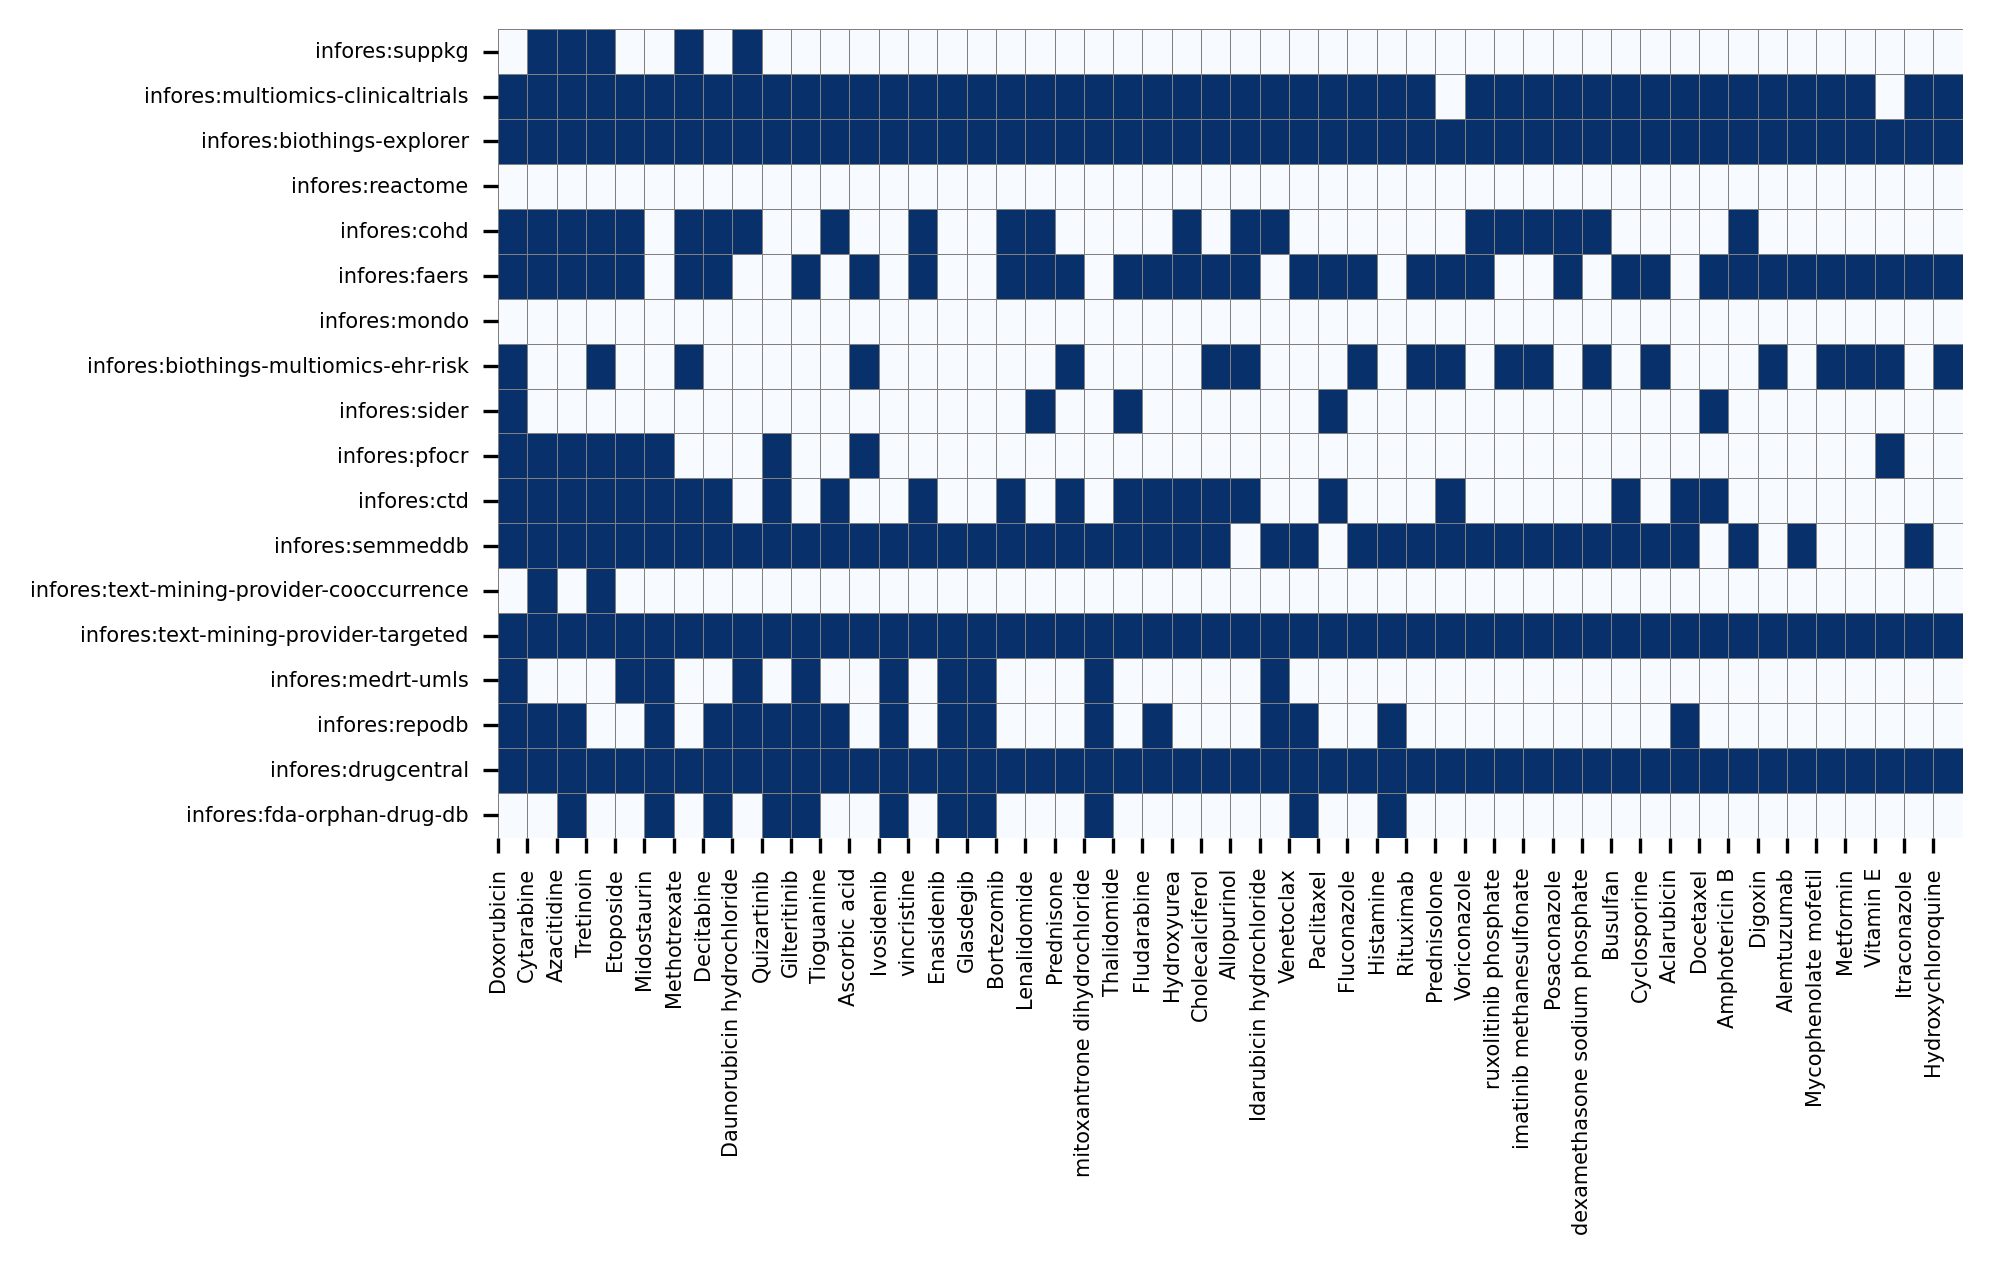

[Text(0.5, 0, 'Doxorubicin'), Text(2.5, 0, 'Azacitidine'), Text(4.5, 0, 'Etoposide'), Text(6.5, 0, 'Methotrexate'), Text(8.5, 0, 'Daunorubicin hydrochloride'), Text(10.5, 0, 'Gilteritinib'), Text(12.5, 0, 'Ascorbic acid'), Text(14.5, 0, 'vincristine'), Text(16.5, 0, 'Glasdegib'), Text(18.5, 0, 'Lenalidomide'), Text(20.5, 0, 'mitoxantrone dihydrochloride'), Text(22.5, 0, 'Fludarabine'), Text(24.5, 0, 'Cholecalciferol'), Text(26.5, 0, 'Idarubicin hydrochloride'), Text(28.5, 0, 'Paclitaxel'), Text(30.5, 0, 'Histamine'), Text(32.5, 0, 'Prednisolone'), Text(34.5, 0, 'ruxolitinib phosphate'), Text(36.5, 0, 'Posaconazole'), Text(38.5, 0, 'Busulfan'), Text(40.5, 0, 'Aclarubicin'), Text(42.5, 0, 'Amphotericin B'), Text(44.5, 0, 'Alemtuzumab'), Text(46.5, 0, 'Metformin'), Text(48.5, 0, 'Itraconazole')]


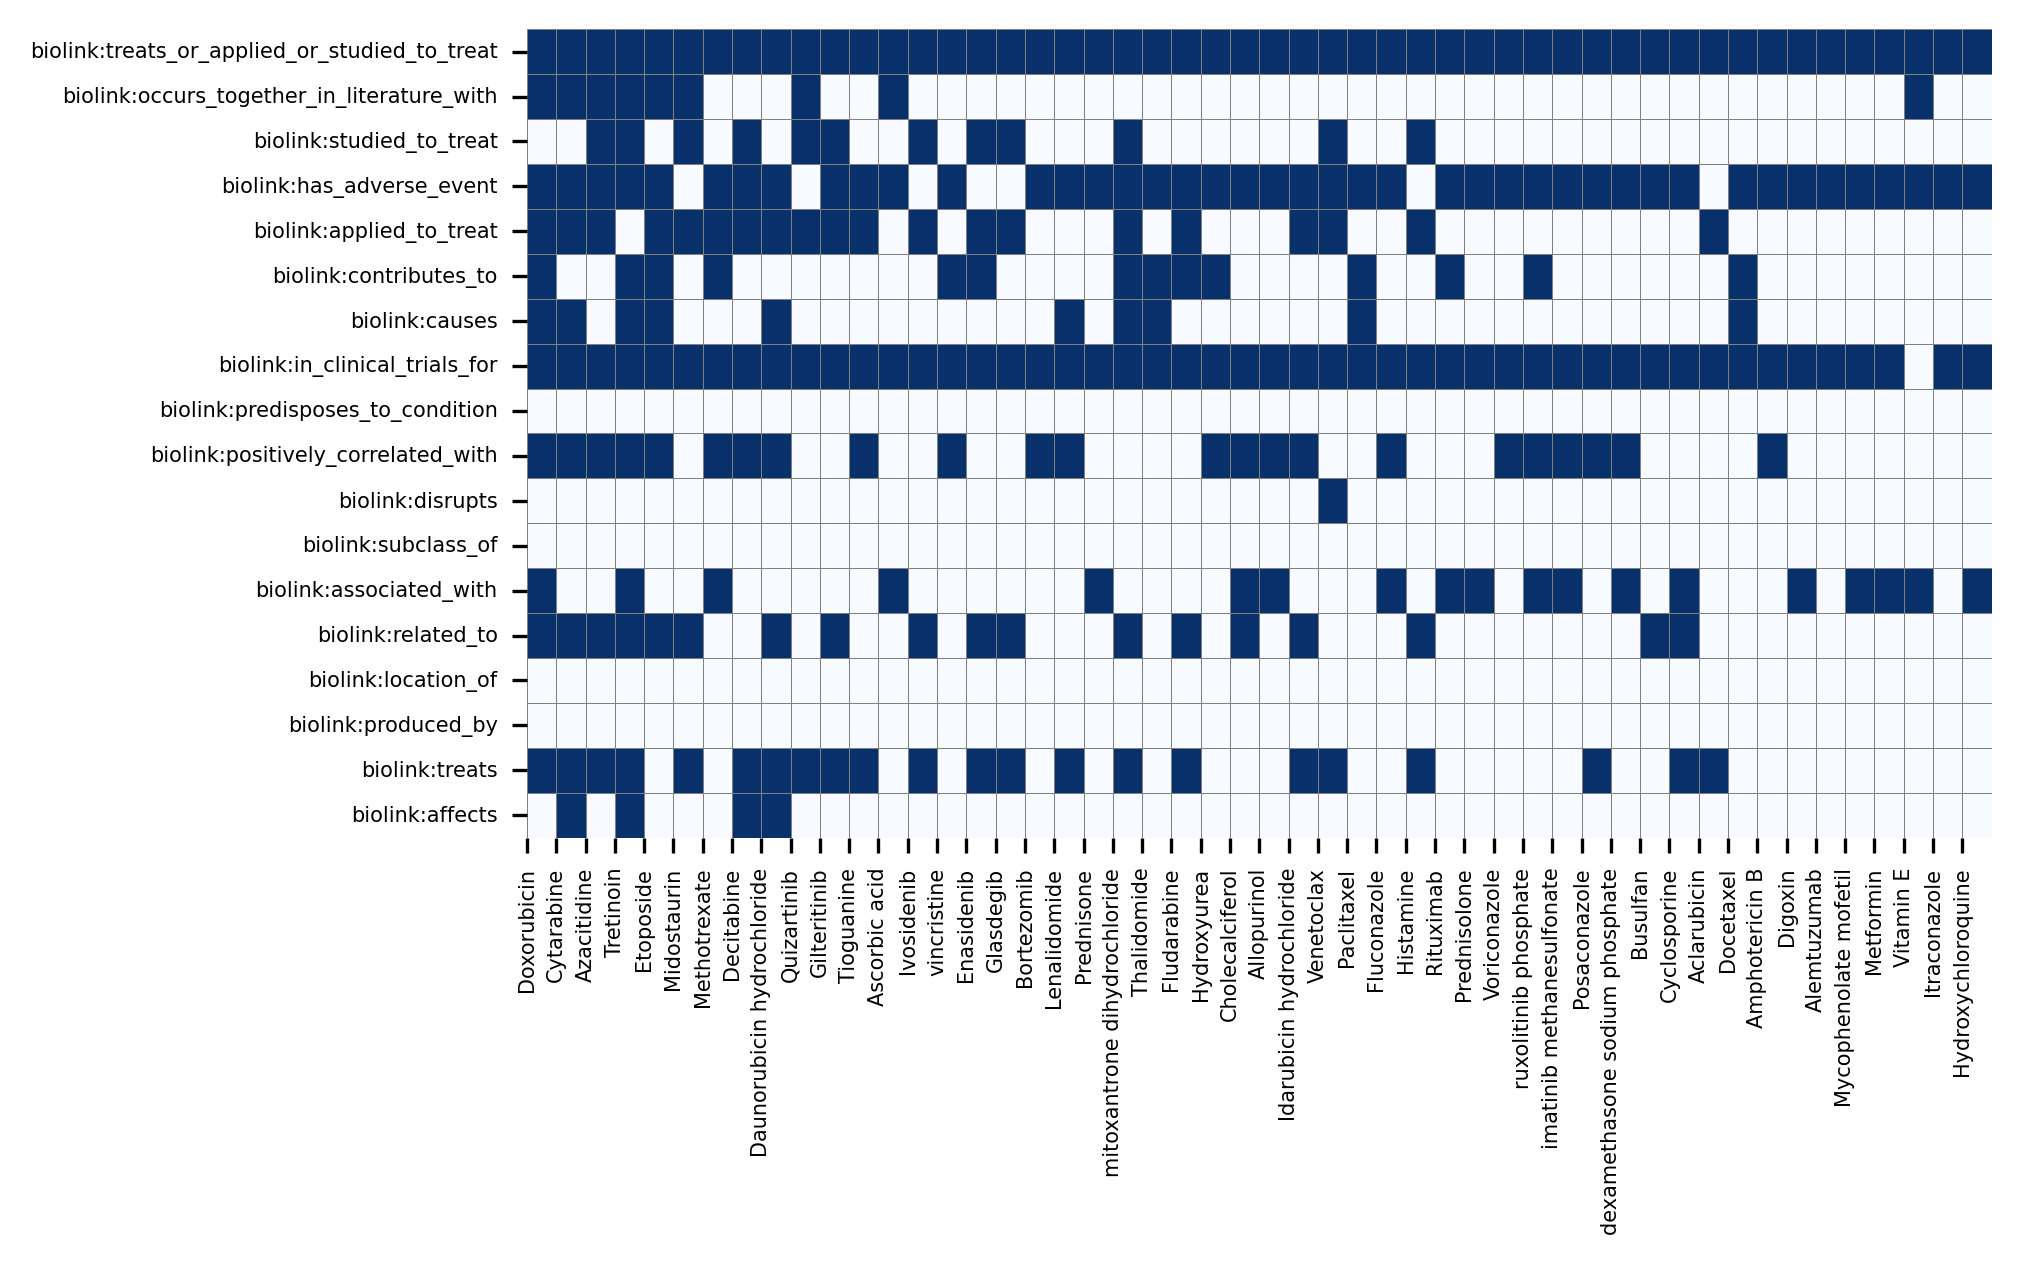

,Doxorubicin,Cytarabine,Azacitidine,Tretinoin,Etoposide,Midostaurin,Methotrexate,Decitabine,Daunorubicin hydrochloride,Quizartinib,...,Amorolfine,Tryptophan,Cholecalciferol,Fructose,Ubiquinol,Vadimezan,Dichloroacetic acid,macrogol,AXL-1717,RXCUI:900963
biolink:treats_or_applied_or_studied_to_treat,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
biolink:occurs_together_in_literature_with,1,1,1,1,1,1,0,0,0,1,...,1,1,1,1,1,1,1,1,1,0
biolink:studied_to_treat,0,0,1,1,0,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
biolink:has_adverse_event,1,1,1,1,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
biolink:applied_to_treat,1,1,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
biolink:contributes_to,1,0,0,1,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:causes,1,1,0,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
biolink:in_clinical_trials_for,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
biolink:predisposes_to_condition,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:positively_correlated_with,1,1,1,1,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,1


In [7]:
# Step 8: Visualize the results
TCT.visulization_one_hop_ranking(result_ranked_by_primary_infores, result_parsed, 
                                num_of_nodes = 50, input_query = input_node_id, 
                                fontsize = 5)

In [8]:
result_ranked_by_primary_infores

,output_node,Name,Num_of_primary_infores,type_of_nodes,unique_predicates
21,CHEBI:28748,Doxorubicin,13,subject,[biolink:treats_or_applied_or_studied_to_treat...
23,CHEBI:28680,Cytarabine,12,subject,[biolink:treats_or_applied_or_studied_to_treat...
29,CHEBI:2038,Azacitidine,12,subject,[biolink:treats_or_applied_or_studied_to_treat...
179,CHEBI:15367,Tretinoin,12,subject,"[biolink:affects, biolink:related_to, biolink:..."
20,CHEBI:4911,Etoposide,10,subject,[biolink:treats_or_applied_or_studied_to_treat...
...,...,...,...,...,...
1875,DRUGBANK:DB06235,Vadimezan,1,subject,[biolink:occurs_together_in_literature_with]
1876,DRUGBANK:DB08809,Dichloroacetic acid,1,subject,[biolink:occurs_together_in_literature_with]
1877,DRUGBANK:DB09287,macrogol,1,subject,[biolink:occurs_together_in_literature_with]
1878,DRUGBANK:DB12802,AXL-1717,1,subject,[biolink:occurs_together_in_literature_with]


In [30]:
# End of the example
